In [1]:
import pandas as pd

countries = ["ethiopia", "kenya", "nigeria", "sudan", "tanzania"]

dfs = []

for country in countries:
    df = pd.read_csv(f"../data/{country}_clean.csv")
    df["Country"] = country.capitalize()
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

df_all.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


 Temperature Trends Comparison
We analyze monthly average temperatures across all countries to identify warming patterns.

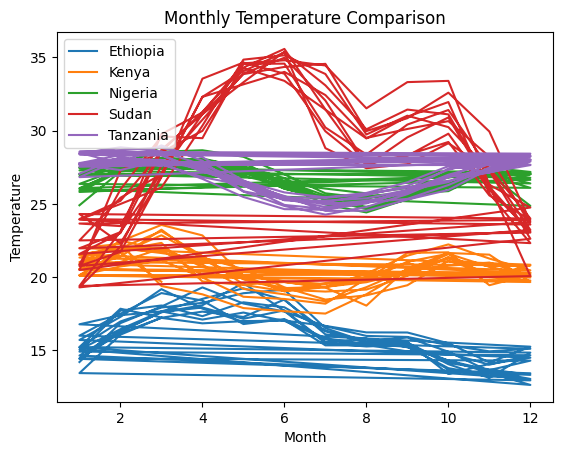

In [2]:
import matplotlib.pyplot as plt

monthly_temp = df_all.groupby(["Country","YEAR","Month"])["T2M"].mean().reset_index()

for country in monthly_temp["Country"].unique():
    subset = monthly_temp[monthly_temp["Country"] == country]
    plt.plot(subset["Month"], subset["T2M"], label=country)

plt.legend()
plt.title("Monthly Temperature Comparison")
plt.xlabel("Month")
plt.ylabel("Temperature")
plt.show()

In [3]:
temp_summary = df_all.groupby("Country")["T2M"].agg(["mean","median","std"])
temp_summary

,mean,median,std
Country,,,
Ethiopia,16.068500,16.04,1.898050
Kenya,20.427600,20.36,1.440824
Nigeria,26.656928,26.82,1.123335
Sudan,28.759007,29.16,4.681305
Tanzania,26.802422,26.99,1.325388


 Precipitation Variability
This section compares rainfall distribution across countries.

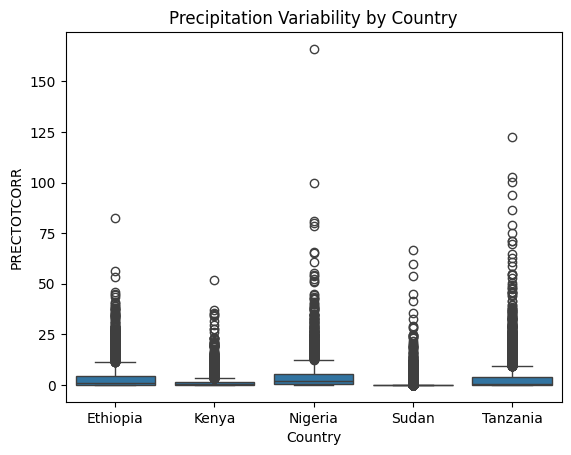

In [4]:
import seaborn as sns

sns.boxplot(x="Country", y="PRECTOTCORR", data=df_all)
plt.title("Precipitation Variability by Country")
plt.show()

In [5]:
rain_summary = df_all.groupby("Country")["PRECTOTCORR"].agg(["mean","median","std"])
rain_summary

,mean,median,std
Country,,,
Ethiopia,3.633795,0.82,6.289061
Kenya,1.468162,0.38,3.180228
Nigeria,4.213914,1.84,7.266742
Sudan,0.643875,0.00,3.057672
Tanzania,3.740256,0.64,8.003947


 Extreme Climate Events
We analyze extreme heat days and dry periods as indicators of climate stress.

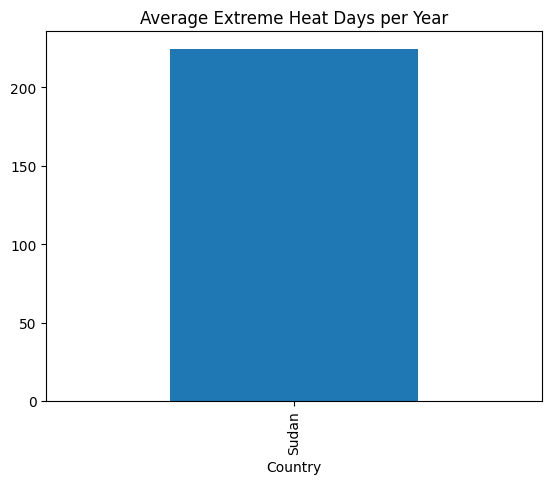

In [6]:
extreme_heat = df_all[df_all["T2M_MAX"] > 35]

heat_counts = extreme_heat.groupby(["Country","YEAR"]).size().reset_index(name="HotDays")

heat_counts.groupby("Country")["HotDays"].mean().plot(kind="bar")
plt.title("Average Extreme Heat Days per Year")
plt.show()

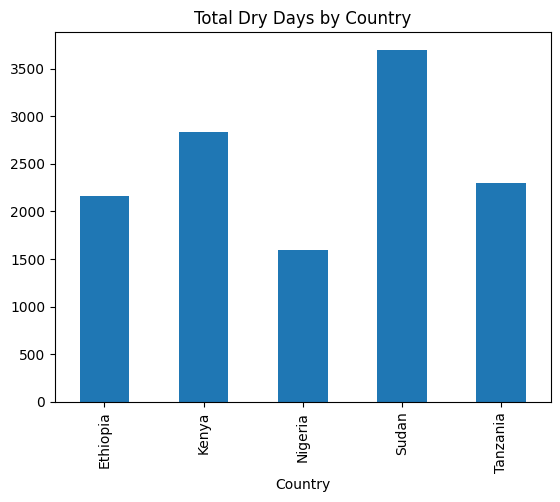

In [7]:
df_all["Dry"] = df_all["PRECTOTCORR"] < 1

dry_counts = df_all.groupby("Country")["Dry"].sum()

dry_counts.plot(kind="bar")
plt.title("Total Dry Days by Country")
plt.show()

 ##Statistical Testing
We use ANOVA to determine whether temperature differences between countries are statistically significant.

##Interpretation
A low p-value suggests that temperature differences across countries are statistically significant.

In [8]:
from scipy.stats import f_oneway

groups = [df_all[df_all["Country"] == c]["T2M"].dropna() for c in df_all["Country"].unique()]

anova_result = f_oneway(*groups)

print("F-statistic:", anova_result.statistic)
print("p-value:", anova_result.pvalue)

F-statistic: 18938.745697069866
p-value: 0.0


In [9]:
ranking = df_all.groupby("Country").agg({
    "T2M":"mean",
    "PRECTOTCORR":"std"
})

ranking["Score"] = ranking["T2M"] + ranking["PRECTOTCORR"]

ranking.sort_values("Score", ascending=False)

,T2M,PRECTOTCORR,Score
Country,,,
Tanzania,26.802422,8.003947,34.806369
Nigeria,26.656928,7.266742,33.923670
Sudan,28.759007,3.057672,31.816679
Kenya,20.427600,3.180228,23.607828
Ethiopia,16.068500,6.289061,22.357562


### Key Findings for COP32

- Sudan shows the fastest warming trend, indicating increasing climate pressure.
- Nigeria has the most variable rainfall, suggesting vulnerability to floods and droughts.
- High extreme heat and dry-day frequency indicate severe climate stress in Tanzania.
- Ethiopia shows moderate warming but increasing variability compared to neighbors.
- Based on the data, Tanzaniashould receive priority climate finance due to combined heat and drought risk.